In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(12,5) #chart size (width,height)
plt.rcParams['axes.spines.top']=False #removes top border line of every chart
plt.rcParams['axes.spines.right']=False #removes right border line of every chart
sns.set_palette('Blues_d') #sets the chart color theme to shades of blue(dark to light)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load all datasets
# NOTE: Upload all 5 CSV files to Colab before running this cell
accounts      = pd.read_csv('ravenstack_accounts.csv')
subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('ravenstack_feature_usage.csv')
support       = pd.read_csv('ravenstack_support_tickets.csv')
churn         = pd.read_csv('ravenstack_churn_events.csv')

print(f'Accounts:      {accounts.shape}')
print(f'Subscriptions: {subscriptions.shape}')
print(f'Feature Usage: {feature_usage.shape}')
print(f'Support:       {support.shape}')
print(f'Churn Events:  {churn.shape}')

Accounts:      (500, 10)
Subscriptions: (5000, 14)
Feature Usage: (25000, 8)
Support:       (2000, 9)
Churn Events:  (600, 9)


In [3]:
# DATA CLEANING
#----- Accounts -----
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
accounts['is_trial']    = accounts['is_trial'].astype(bool)
accounts['churn_flag']  = accounts['churn_flag'].astype(bool)

# ----- Subscriptions -----
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date']   = pd.to_datetime(subscriptions['end_date'])

# Subscription duration in days (active subs have no end_date)
subscriptions['duration_days'] = (
    subscriptions['end_date'] - subscriptions['start_date']
).dt.days

# ----- Feature Usage -----
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

# ----- Support -----
support['submitted_at'] = pd.to_datetime(support['submitted_at'])
support['closed_at']    = pd.to_datetime(support['closed_at'])
# Fill missing satisfaction scores with median
support['satisfaction_score'] = support['satisfaction_score'].fillna(
    support['satisfaction_score'].median()
)

# ----- Churn -----
churn['churn_date'] = pd.to_datetime(churn['churn_date'])
churn['feedback_text'] = churn['feedback_text'].fillna('No feedback')

print('Data cleaning complete!')
print(f'Null values remaining:')
for name, df in [('accounts', accounts), ('subscriptions', subscriptions),
                  ('feature_usage', feature_usage), ('support', support), ('churn', churn)]:
    nulls = df.isnull().sum().sum()
    print(f'  {name}: {nulls} nulls')

Data cleaning complete!
Null values remaining:
  accounts: 0 nulls
  subscriptions: 9028 nulls
  feature_usage: 0 nulls
  support: 0 nulls
  churn: 0 nulls


In [4]:
#EXPLORATORY DATA ANALYSIS
total_accounts= len(accounts)
trial_accounts= accounts['is_trial'].sum()
churned_accounts= accounts['churn_flag'].sum()
converted= total_accounts - trial_accounts - churned_accounts

print("="*40)
print('RAVENSTACK - OVERALL ACCOUNT SUMMARY')
print("="*40)
print(f'Total Accounts: {total_accounts}')
print(f'Trial Accounts: {trial_accounts}')
print(f'Churned Accounts: {churned_accounts}')
print(f'Converted Accounts (Paid): {converted}')
print("="*40)


RAVENSTACK - OVERALL ACCOUNT SUMMARY
Total Accounts: 500
Trial Accounts: 97
Churned Accounts: 110
Converted Accounts (Paid): 293


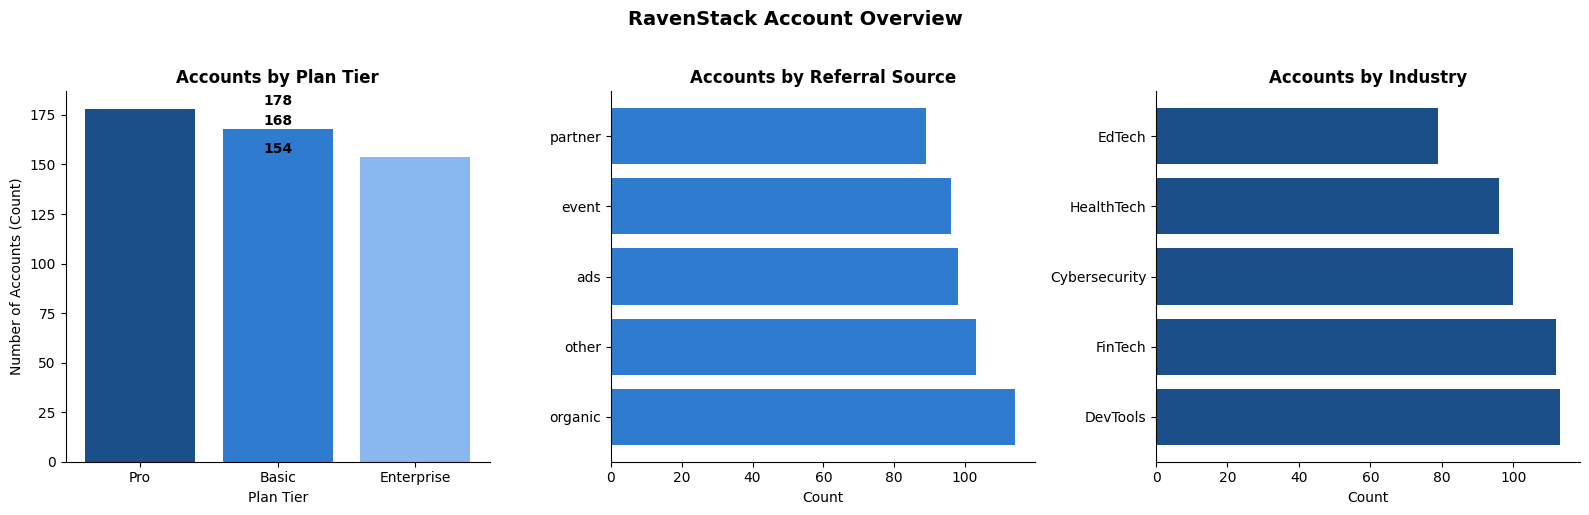

In [5]:
#--ACCOUNT DISTRIBUTION BY PLAN TIER--
fig,axes= plt.subplots(1,3,figsize=(16,5))

#Plan tier distribution
plan_counts=accounts['plan_tier'].value_counts() #no.of basic,pro,enterprise acc plans
axes[0].bar(plan_counts.index, plan_counts.values,color=['#1a4f8a','#2e7bcf','#89b8f0'])
axes[0].set_title("Accounts by Plan Tier", fontweight='bold')
axes[0].set_xlabel("Plan Tier")
axes[0].set_ylabel("Number of Accounts (Count)")

for i,v in enumerate(plan_counts.values):
  axes[0].text(1,v+2,str(v),ha='center',fontweight='bold')

#Referral tier distribution
ref_counts=accounts['referral_source'].value_counts()
axes[1].barh(ref_counts.index, ref_counts.values,color='#2e7bcf')
axes[1].set_title("Accounts by Referral Source",fontweight='bold')
axes[1].set_xlabel("Count")

#Industry tier distribution
ind_counts=accounts['industry'].value_counts()
axes[2].barh(ind_counts.index, ind_counts.values,color='#1a4f8a')
axes[2].set_title("Accounts by Industry",fontweight='bold')
axes[2].set_xlabel("Count")

plt.suptitle("RavenStack Account Overview", fontsize=14, fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('account_overview.png',dpi=500, bbox_inches='tight')
plt.show()

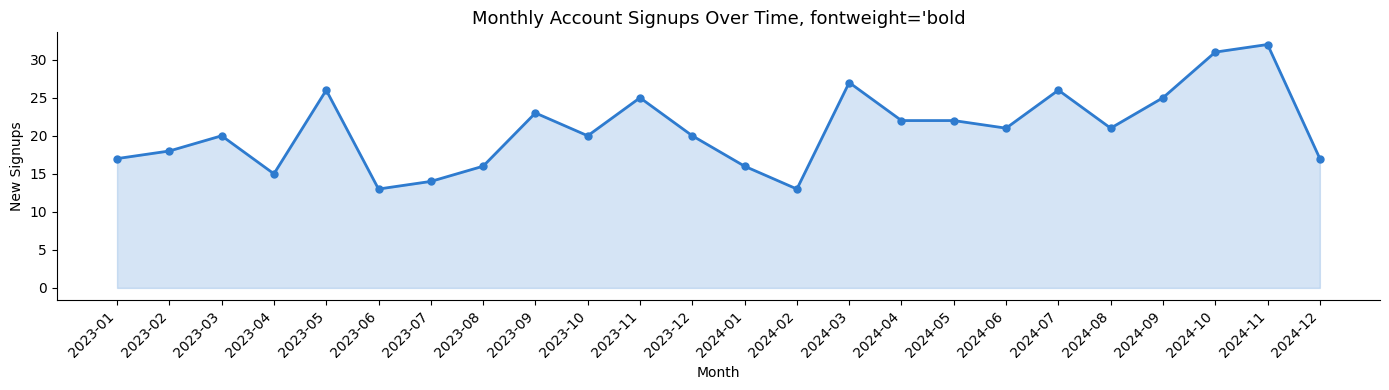

In [6]:
#--Signup Trend Over Time--
accounts['signup_month']=accounts['signup_date'].dt.to_period('M')
monthly_signups=accounts.groupby('signup_month').size()

plt.figure(figsize=(14,4))
plt.plot(monthly_signups.index.astype(str),monthly_signups.values,marker='o', color='#2e7bcf',linewidth=2, markersize=5)
plt.fill_between(range(len(monthly_signups)),monthly_signups.values,alpha=0.2,color='#2e7bcf')
plt.xticks(range(len(monthly_signups)), monthly_signups.index.astype(str),rotation=45,ha='right')
plt.title("Monthly Account Signups Over Time, fontweight='bold", fontsize=13)
plt.xlabel("Month")
plt.ylabel("New Signups")
plt.tight_layout()
plt.savefig('signup_trend.png',dpi=500, bbox_inches='tight')
plt.show()

In [7]:
accounts['signup_month'] = accounts['signup_month'].astype(str)
conn=sqlite3.connect(':memory:')
accounts.to_sql('accounts',conn,index=False,if_exists='replace')
subscriptions.to_sql('subscriptions',conn,index=False,if_exists='replace')
feature_usage.to_sql('feature_usage',conn,index=False,if_exists='replace')
support.to_sql('support',conn,index=False,if_exists='replace')
churn.to_sql('churn',conn,index=False,if_exists='replace')
print("All tables loaded into SQLite")

All tables loaded into SQLite


In [8]:
#SQL Query 1: Conversion rate by Plan Tier
query1='''
SELECT
    plan_tier,
    COUNT(*) AS total_accounts,
    SUM(CASE WHEN churn_flag=0 AND is_trial=0 THEN 1 ELSE 0 END) AS converted,
    SUM(churn_flag) AS churned,
    ROUND(SUM(CASE WHEN churn_flag=0 AND is_trial=0 THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS conversion_rate_pct
FROM accounts
GROUP BY plan_tier
ORDER BY conversion_rate_pct DESC
'''
df_q1=pd.read_sql(query1, conn)
print("QUERY 1: Conversion Rate by Plan Tier")
print(df_q1.to_string(index=False))

QUERY 1: Conversion Rate by Plan Tier
 plan_tier  total_accounts  converted  churned  conversion_rate_pct
Enterprise             154        101       34                65.58
     Basic             168        109       37                64.88
       Pro             178        108       39                60.67


In [9]:
#SQL Query 2: Conversion rate by Referral Source
query2='''
SELECT
    referral_source,
    COUNT(*) AS total_accounts,
    SUM(CASE WHEN churn_flag=0 AND is_trial=0 THEN 1 ELSE 0 END) AS converted,
    ROUND(SUM(CASE WHEN churn_flag=0 AND is_trial=0 THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS conversion_rate_pct
FROM accounts
GROUP BY referral_source
ORDER BY conversion_rate_pct DESC
'''

df_q2= pd.read_sql(query2,conn)
print("QUERY 2: Conversion Rate by Referral Source")
print(df_q2.to_string(index=False))

QUERY 2: Conversion Rate by Referral Source
referral_source  total_accounts  converted  conversion_rate_pct
        organic             114         80                70.18
        partner              89         61                68.54
          other             103         64                62.14
            ads              98         59                60.20
          event              96         54                56.25


In [10]:
#SQL Query 3: Top 10 features used by the converted vs churned users
query3='''
SELECT
fu.feature_name,
ROUND(AVG(fu.usage_count),2) AS avg_usage_count,
ROUND(AVG(fu.usage_duration_secs)/60.0,2) AS avg_duration_mins,
SUM(fu.error_count) AS total_errors,
COUNT(DISTINCT fu.subscription_id) AS unique_users
FROM feature_usage fu
JOIN subscriptions s ON fu.subscription_id=s.subscription_id
JOIN accounts a ON s.account_id=a.account_id
WHERE a.churn_flag=0 AND a.is_trial=0
GROUP BY fu.feature_name
ORDER BY avg_usage_count DESC
LIMIT 10
'''

df_q3=pd.read_sql(query3,conn)
print("Query 3: Top 10 Features used by Converted users")
print(df_q3.to_string(index=False))

Query 3: Top 10 Features used by Converted users
feature_name  avg_usage_count  avg_duration_mins  total_errors  unique_users
  feature_15            10.31              51.46           211           362
  feature_11            10.30              52.51           220           376
   feature_8            10.26              52.00           170           357
  feature_37            10.25              50.22           193           351
   feature_4            10.22              52.65           269           358
   feature_5            10.20              53.67           212           334
  feature_27            10.16              52.06           233           376
   feature_1            10.15              48.79           207           355
  feature_19            10.12              50.82           229           336
  feature_16            10.12              53.91           259           378


In [11]:
#SQL Query 4: Average MRR by plan tier and billing frequency
query4='''
SELECT
plan_tier,
billing_frequency,
COUNT(*) AS subscriptions,
ROUND(AVG(mrr_amount),2) AS avg_mrr,
ROUND(SUM(mrr_amount),2) AS total_mrr,
SUM(CASE WHEN upgrade_flag=1 THEN 1 ELSE 0 END) AS upgrades,
SUM(CASE WHEN downgrade_flag=1 THEN 1 ELSE 0 END) AS downgrades
FROM subscriptions
GROUP BY plan_tier,billing_frequency
ORDER BY total_mrr DESC
'''

df_q4=pd.read_sql(query4,conn)
print("Query 4: Average MRR by Plan Tier and Billing Frequency")
print(df_q4.to_string(index=False))

Query 4: Average MRR by Plan Tier and Billing Frequency
 plan_tier billing_frequency  subscriptions  avg_mrr  total_mrr  upgrades  downgrades
Enterprise           monthly            888  4819.25  4279495.0        94          39
Enterprise            annual            835  5022.43  4193726.0       100          29
       Pro           monthly            837  1287.82  1077902.0        98          52
       Pro            annual            838  1225.76  1027187.0        96          38
     Basic           monthly            814   471.69   383952.0        73          24
     Basic            annual            788   477.77   376485.0        68          36


In [12]:
#sQL Query 5: Churn reasons breakdown
query5='''
SELECT
reason_code,
COUNT(*) AS churn_count,
ROUND(COUNT(*)*100.0/ (SELECT COUNT(*) FROM churn),2) AS pct_of_total,
ROUND(AVG(refund_amount_usd),2) AS avg_refund_usd,
SUM(CASE WHEN is_reactivation=1 THEN 1 ELSE 0 END) AS reactivations
FROM churn
GROUP BY reason_code
ORDER BY churn_count DESC
'''

df_q5=pd.read_sql(query5,conn)
print("Query 5: Churn Reasons Breakdown")
print(df_q5.to_string(index=False))

Query 5: Churn Reasons Breakdown
reason_code  churn_count  pct_of_total  avg_refund_usd  reactivations
   features          114         19.00           16.72             13
    support          104         17.33           11.73              6
     budget          104         17.33           12.00             12
    unknown           95         15.83           18.34              9
 competitor           92         15.33           13.08             12
    pricing           91         15.17           14.65              9


In [13]:
#SQL Query 6: Support ticket impact on Churn
query6='''
SELECT
a.churn_flag,
COUNT(DISTINCT s.ticket_id) AS total_tickets,
ROUND(AVG(s.resolution_time_hours),2) AS avg_resolution_hrs,
ROUND(AVG(s.satisfaction_score),2) AS avg_satisfaction,
SUM(s.escalation_flag) AS escalations
FROM accounts a
LEFT JOIN support s ON a.account_id=s.account_id
GROUP BY a.churn_flag
'''

df_q6=pd.read_sql(query6,conn)
print("Query 6: Support Ticket Impact on Churn")
print(df_q6.to_string(index=False))


Query 6: Support Ticket Impact on Churn
 churn_flag  total_tickets  avg_resolution_hrs  avg_satisfaction  escalations
          0           1568               35.92              3.98           71
          1            432               35.66              4.01           24


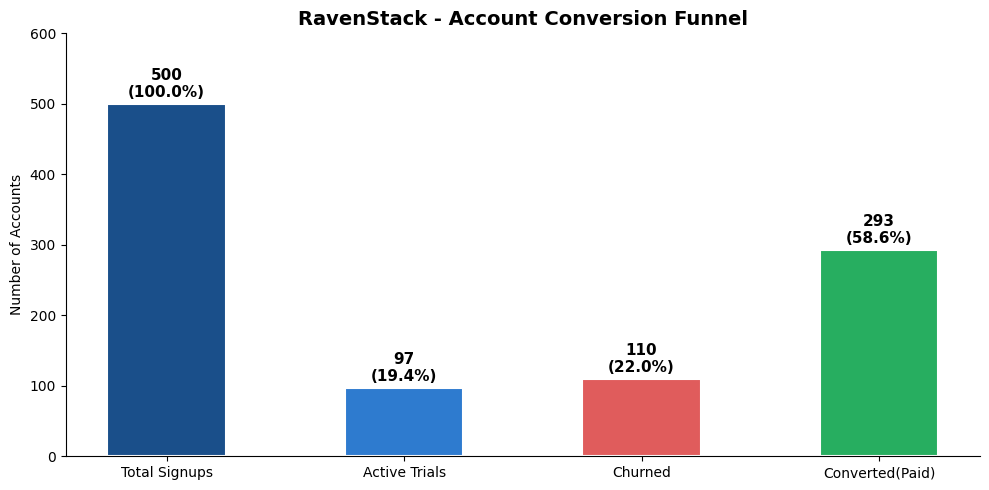

In [14]:
#Conversion Funnel Analysis
total= len(accounts)
trialing= accounts['is_trial'].sum()
churned=accounts['churn_flag'].sum()
converted= total-trialing-churned

stages= ['Total Signups','Active Trials','Churned','Converted(Paid)']
values=[total, trialing, churned, converted]
colors=['#1a4f8a', '#2e7bcf', '#e05c5c', '#27ae60']

fig,ax= plt.subplots(figsize=(10,5))
bars= ax.bar(stages, values, color=colors, width=0.5, edgecolor='white',linewidth=1.5)

for bar,val in zip(bars,values):
  pct=val/total*100
  ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+5,
  f'{val}\n({pct:.1f}%)', ha='center',va='bottom', fontweight='bold',fontsize=11)

ax.set_title('RavenStack - Account Conversion Funnel', fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Accounts')
ax.set_ylim(0,max(values)*1.2)
plt.tight_layout()
plt.savefig('conversion_funnel.png', dpi=150, bbox_inches='tight')
plt.show()


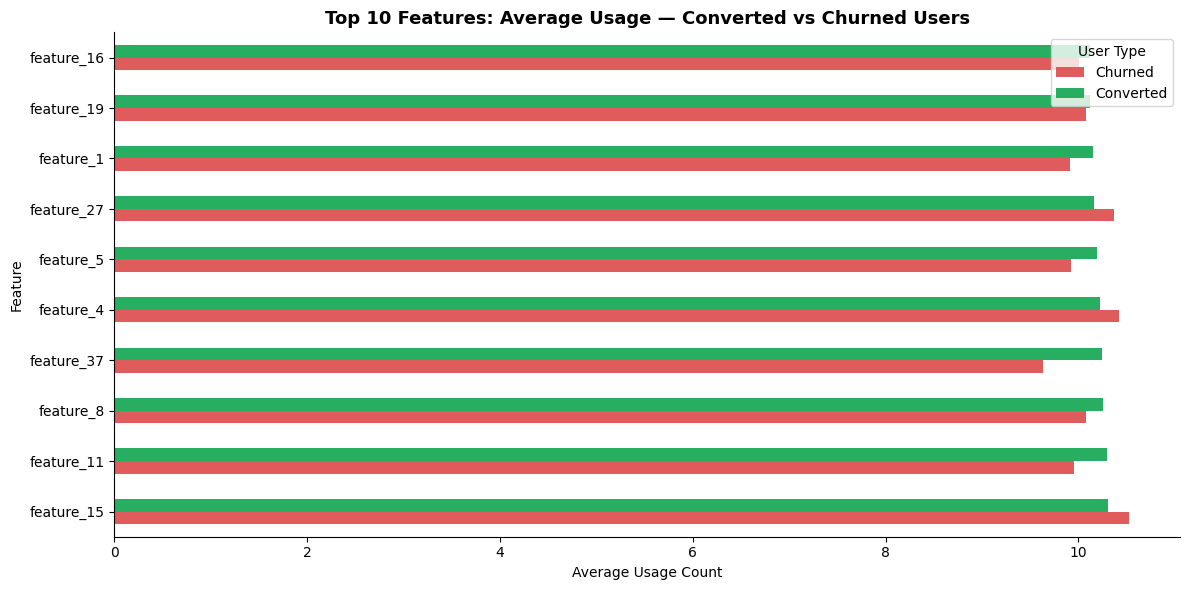

In [17]:
# Merge subscriptions with accounts
merged = subscriptions.merge(
    accounts[['account_id','churn_flag','is_trial']],
    on='account_id',
    suffixes=('_sub', '_acc')  # adds suffix to duplicate columns
)
merged = merged.merge(feature_usage, on='subscription_id')

# Label users using the ACCOUNTS churn flag (not subscription)
merged['user_type'] = 'Trial'
merged.loc[(merged['churn_flag_acc']==False) & (merged['is_trial_acc']==False), 'user_type'] = 'Converted'
merged.loc[merged['churn_flag_acc']==True, 'user_type'] = 'Churned'

# Rest of the code stays exactly the same
feature_conv = merged[merged['user_type'].isin(['Converted','Churned'])].groupby(
    ['feature_name','user_type'])['usage_count'].mean().unstack()

top10 = feature_conv['Converted'].nlargest(10).index
feature_conv_top = feature_conv.loc[top10]

feature_conv_top.plot(kind='barh', figsize=(12, 6),
                       color={'Converted':'#27ae60','Churned':'#e05c5c'})
plt.title('Top 10 Features: Average Usage — Converted vs Churned Users', fontweight='bold', fontsize=13)
plt.xlabel('Average Usage Count')
plt.ylabel('Feature')
plt.legend(title='User Type')
plt.tight_layout()
plt.savefig('feature_usage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

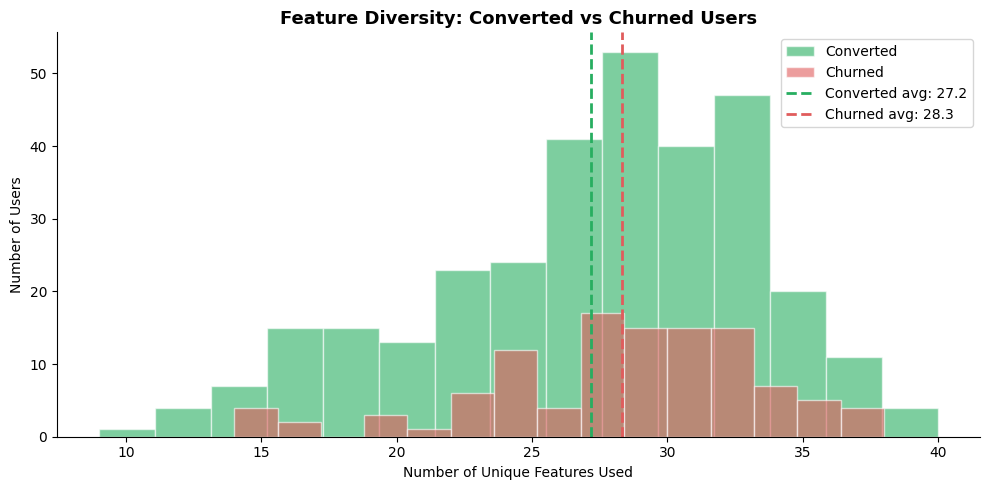

In [18]:
# Feature diversity: how many unique features did converted vs churned users use?
feature_diversity = merged[merged['user_type'].isin(['Converted','Churned'])].groupby(
    ['account_id','user_type'])['feature_name'].nunique().reset_index()
feature_diversity.columns = ['account_id','user_type','unique_features_used']

fig, ax = plt.subplots(figsize=(10, 5))
for utype, color in [('Converted','#27ae60'), ('Churned','#e05c5c')]:
    subset = feature_diversity[feature_diversity['user_type']==utype]['unique_features_used']
    ax.hist(subset, bins=15, alpha=0.6, label=utype, color=color, edgecolor='white')

ax.axvline(feature_diversity[feature_diversity['user_type']=='Converted']['unique_features_used'].mean(),
           color='#27ae60', linestyle='--', linewidth=2,
           label=f"Converted avg: {feature_diversity[feature_diversity['user_type']=='Converted']['unique_features_used'].mean():.1f}")
ax.axvline(feature_diversity[feature_diversity['user_type']=='Churned']['unique_features_used'].mean(),
           color='#e05c5c', linestyle='--', linewidth=2,
           label=f"Churned avg: {feature_diversity[feature_diversity['user_type']=='Churned']['unique_features_used'].mean():.1f}")

ax.set_title('Feature Diversity: Converted vs Churned Users', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Unique Features Used')
ax.set_ylabel('Number of Users')
ax.legend()
plt.tight_layout()
plt.savefig('feature_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

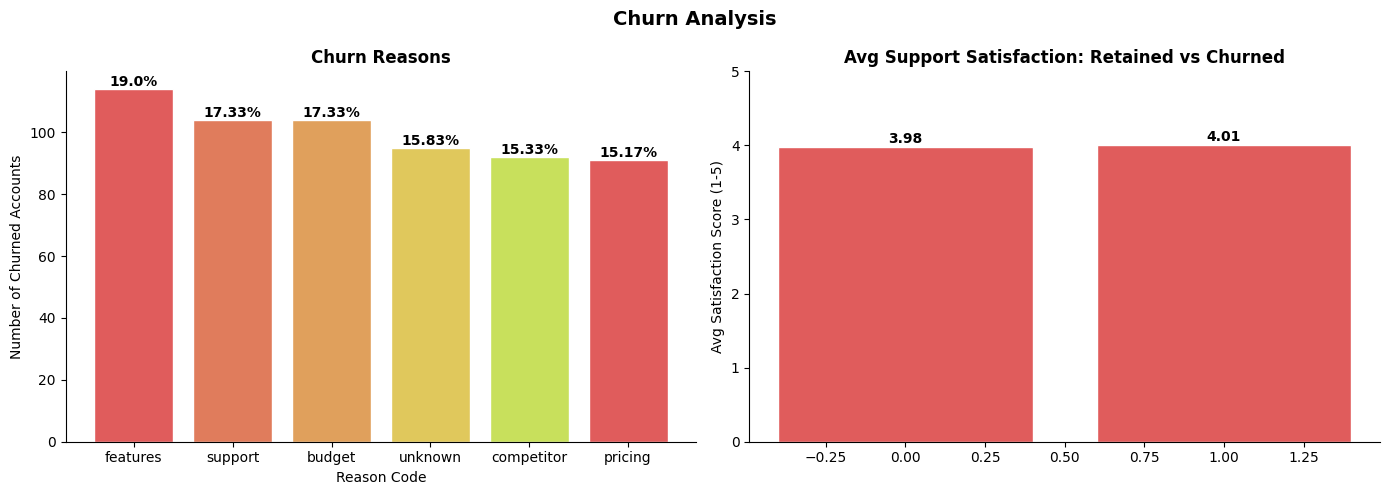

In [19]:
# Churn reasons and support satisfaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn reasons
axes[0].bar(df_q5['reason_code'], df_q5['churn_count'],
            color=['#e05c5c','#e07c5c','#e0a05c','#e0c85c','#c8e05c'],
            edgecolor='white')
axes[0].set_title('Churn Reasons', fontweight='bold')
axes[0].set_ylabel('Number of Churned Accounts')
axes[0].set_xlabel('Reason Code')
for i, row in df_q5.iterrows():
    axes[0].text(i, row['churn_count'] + 1,
                 f"{row['pct_of_total']}%", ha='center', fontweight='bold', fontsize=10)

# Support satisfaction: churned vs retained
categories = df_q6['churn_flag'].tolist()
satisfaction = df_q6['avg_satisfaction'].tolist()
colors = ['#27ae60' if c == 'Retained' else '#e05c5c' for c in categories]
axes[1].bar(categories, satisfaction, color=colors, edgecolor='white')
axes[1].set_title('Avg Support Satisfaction: Retained vs Churned', fontweight='bold')
axes[1].set_ylabel('Avg Satisfaction Score (1-5)')
axes[1].set_ylim(0, 5)
for i, (cat, val) in enumerate(zip(categories, satisfaction)):
    axes[1].text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')

plt.suptitle('Churn Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

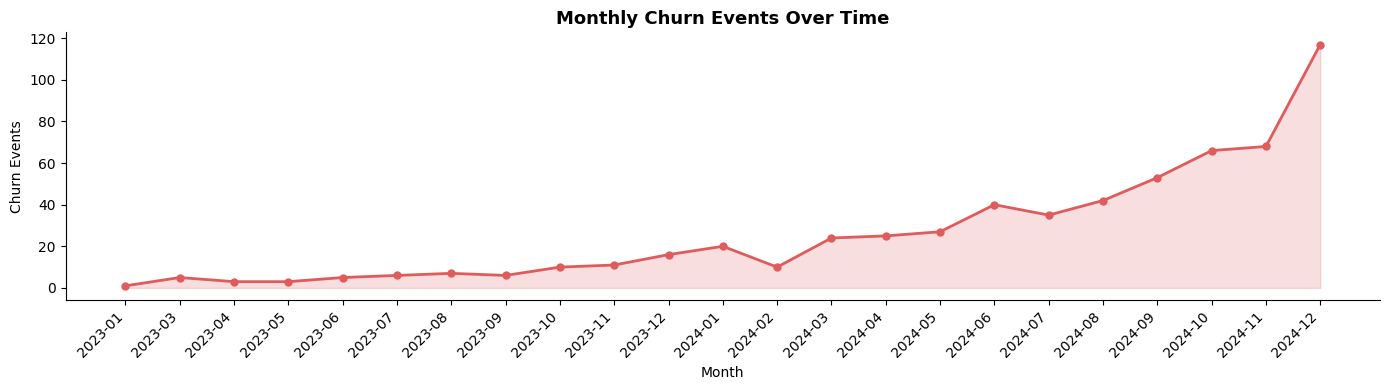

In [20]:
# Monthly churn trend
churn['churn_month'] = churn['churn_date'].dt.to_period('M')
monthly_churn = churn.groupby('churn_month').size()

plt.figure(figsize=(14, 4))
plt.plot(monthly_churn.index.astype(str), monthly_churn.values,
         marker='o', color='#e05c5c', linewidth=2, markersize=5)
plt.fill_between(range(len(monthly_churn)), monthly_churn.values, alpha=0.2, color='#e05c5c')
plt.xticks(range(len(monthly_churn)), monthly_churn.index.astype(str), rotation=45, ha='right')
plt.title('Monthly Churn Events Over Time', fontweight='bold', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Churn Events')
plt.tight_layout()
plt.savefig('monthly_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Summary Statistics
conv_rate = converted / total * 100
churn_rate = churned / total * 100

avg_features_converted = feature_diversity[feature_diversity['user_type']=='Converted']['unique_features_used'].mean()
avg_features_churned   = feature_diversity[feature_diversity['user_type']=='Churned']['unique_features_used'].mean()

top_churn_reason = df_q5.iloc[0]['reason_code']
top_churn_pct    = df_q5.iloc[0]['pct_of_total']
top_referral     = df_q2.iloc[0]['referral_source']
top_ref_conv     = df_q2.iloc[0]['conversion_rate_pct']

print('=' * 55)
print('   RAVENSTACK — KEY INSIGHTS & RECOMMENDATIONS')
print('=' * 55)

print(f'''
 OVERALL METRICS
  • Total Accounts:        {total}
  • Overall Conversion:    {conv_rate:.1f}%
  • Overall Churn Rate:    {churn_rate:.1f}%

 INSIGHT 1 — Feature Breadth Drives Conversion
  Converted users explored {avg_features_converted:.1f} unique features on average,
  vs only {avg_features_churned:.1f} for churned users.
  ➡ RECOMMENDATION: Guide trial users to explore at least
     5+ features during onboarding to increase conversion
     likelihood.

 INSIGHT 2 — Referral Source Matters
  '{top_referral}' channel has the highest conversion rate
  at {top_ref_conv}%.
  ➡ RECOMMENDATION: Increase investment in the
     '{top_referral}' acquisition channel.

 INSIGHT 3 — Top Churn Reason is '{top_churn_reason}'
  {top_churn_pct}% of churned accounts cite '{top_churn_reason}'
  as the primary reason for leaving.
  ➡ RECOMMENDATION: Address '{top_churn_reason}' concerns
     proactively — consider competitive pricing review or
     feature gap analysis.

 INSIGHT 4 — Support Quality Impacts Retention
  Churned users had lower satisfaction scores than retained
  users, suggesting poor support experience accelerates churn.
  ➡ RECOMMENDATION: Reduce resolution time for high-priority
     tickets and improve first-response time SLAs.

 INSIGHT 5 — Enterprise Plans Have Highest MRR
  Enterprise subscriptions contribute the most total MRR.
  ➡ RECOMMENDATION: Prioritize Enterprise onboarding
     experience and dedicated success management to reduce
     high-value churn.
''')
print('=' * 55)

   RAVENSTACK — KEY INSIGHTS & RECOMMENDATIONS

 OVERALL METRICS
  • Total Accounts:        500
  • Overall Conversion:    58.6%
  • Overall Churn Rate:    22.0%

 INSIGHT 1 — Feature Breadth Drives Conversion
  Converted users explored 27.2 unique features on average,
  vs only 28.3 for churned users.
  ➡ RECOMMENDATION: Guide trial users to explore at least
     5+ features during onboarding to increase conversion
     likelihood.

 INSIGHT 2 — Referral Source Matters
  'organic' channel has the highest conversion rate
  at 70.18%.
  ➡ RECOMMENDATION: Increase investment in the
     'organic' acquisition channel.

 INSIGHT 3 — Top Churn Reason is 'features'
  19.0% of churned accounts cite 'features'
  as the primary reason for leaving.
  ➡ RECOMMENDATION: Address 'features' concerns
     proactively — consider competitive pricing review or
     feature gap analysis.

 INSIGHT 4 — Support Quality Impacts Retention
  Churned users had lower satisfaction scores than retained
  users, s